In [2]:
!pip install pyserial

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 73.2 kB/s eta 0:00:00a 0:00:01m


In [5]:
import serial
import time
import csv

# CHANGE 'COM3' to your Arduino's port (e.g., '/dev/ttyUSB0' on Mac/Linux)
ser = serial.Serial('/dev/ttyUSB0', 115200)
filename = "raw_temp_data.csv"

print("Logging data... Press Ctrl+C to stop.")
with open(filename, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(["Raw_Temp"])
    
    try:
        while True:
            if ser.in_waiting > 0:
                line = ser.readline().decode('utf-8').strip()
                writer.writerow([line])
                print(f"Recorded: {line}")
    except KeyboardInterrupt:
        print("Data collection complete.")
        ser.close()

Logging data... Press Ctrl+C to stop.
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Recorded: 30.70
Re

--- Optimization Results ---
Best SMA Window Size: 5 (RMSE: 0.0064)
Best EMA Alpha:       0.2 (RMSE: 0.0064)

WINNER: SMA filter with window = 5


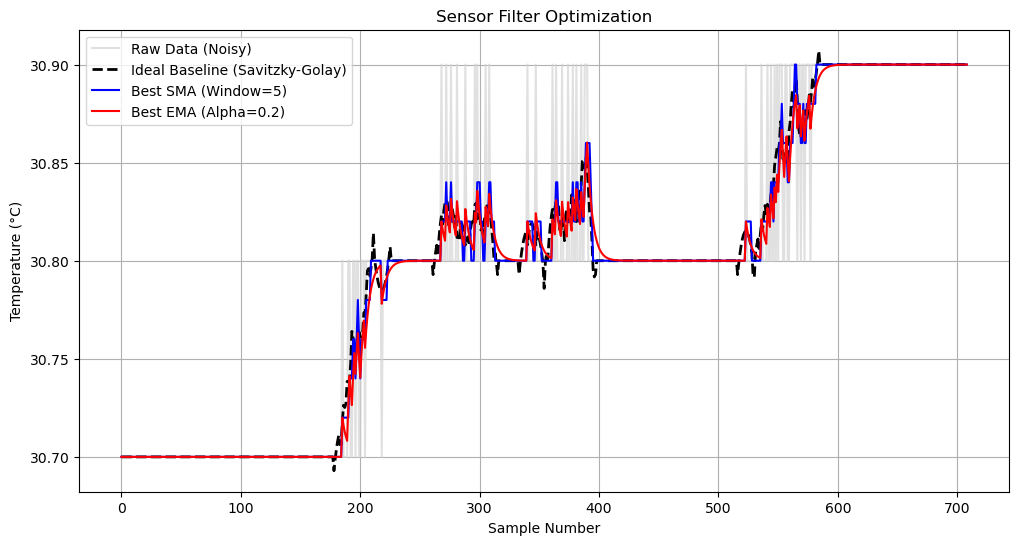

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from sklearn.metrics import mean_squared_error

# 1. Load Data
df = pd.read_csv("raw_temp_data.csv")
raw_data = df['Raw_Temp'].values

# 2. Create "Ground Truth" Baseline using Savitzky-Golay (Offline, zero-phase filter)
# Window size 15, polynomial order 3 (Adjust if your data is very short)
baseline = savgol_filter(raw_data, window_length=15, polyorder=3)

# 3. Define Parameter Grids to Test
window_sizes = [3, 5, 7, 10, 15]          # For Simple Moving Average (SMA)
alpha_values = [0.1, 0.2, 0.3, 0.5, 0.8]  # For Exponential Moving Average (EMA)

best_sma_rmse = float('inf')
best_sma_window = None
best_sma_data = None

best_ema_rmse = float('inf')
best_ema_alpha = None
best_ema_data = None

# 4. Optimize Simple Moving Average (SMA)
for w in window_sizes:
    # Calculate SMA, fill initial NaNs with the first valid reading
    sma = df['Raw_Temp'].rolling(window=w, min_periods=1).mean().values
    rmse = np.sqrt(mean_squared_error(baseline, sma))
    if rmse < best_sma_rmse:
        best_sma_rmse = rmse
        best_sma_window = w
        best_sma_data = sma

# 5. Optimize Exponential Moving Average (EMA)
for a in alpha_values:
    # Calculate EMA
    ema = df['Raw_Temp'].ewm(alpha=a, adjust=False).mean().values
    rmse = np.sqrt(mean_squared_error(baseline, ema))
    if rmse < best_ema_rmse:
        best_ema_rmse = rmse
        best_ema_alpha = a
        best_ema_data = ema

# 6. Print Results
print("--- Optimization Results ---")
print(f"Best SMA Window Size: {best_sma_window} (RMSE: {best_sma_rmse:.4f})")
print(f"Best EMA Alpha:       {best_ema_alpha} (RMSE: {best_ema_rmse:.4f})")

if best_ema_rmse < best_sma_rmse:
    print(f"\nWINNER: EMA filter with alpha = {best_ema_alpha}")
else:
    print(f"\nWINNER: SMA filter with window = {best_sma_window}")

# 7. Plotting
plt.figure(figsize=(12, 6))
plt.plot(raw_data, label='Raw Data (Noisy)', color='lightgray', alpha=0.7)
plt.plot(baseline, label='Ideal Baseline (Savitzky-Golay)', color='black', linewidth=2, linestyle='--')
plt.plot(best_sma_data, label=f'Best SMA (Window={best_sma_window})', color='blue')
plt.plot(best_ema_data, label=f'Best EMA (Alpha={best_ema_alpha})', color='red')

plt.title("Sensor Filter Optimization")
plt.xlabel("Sample Number")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

--- Rigorous Optimization Results ---
Best SMA Window Size: 8 (RMSE: 0.00565)
Best EMA Alpha:       0.200 (RMSE: 0.00595)

MATHEMATICAL WINNER: SMA filter (Window = 8)


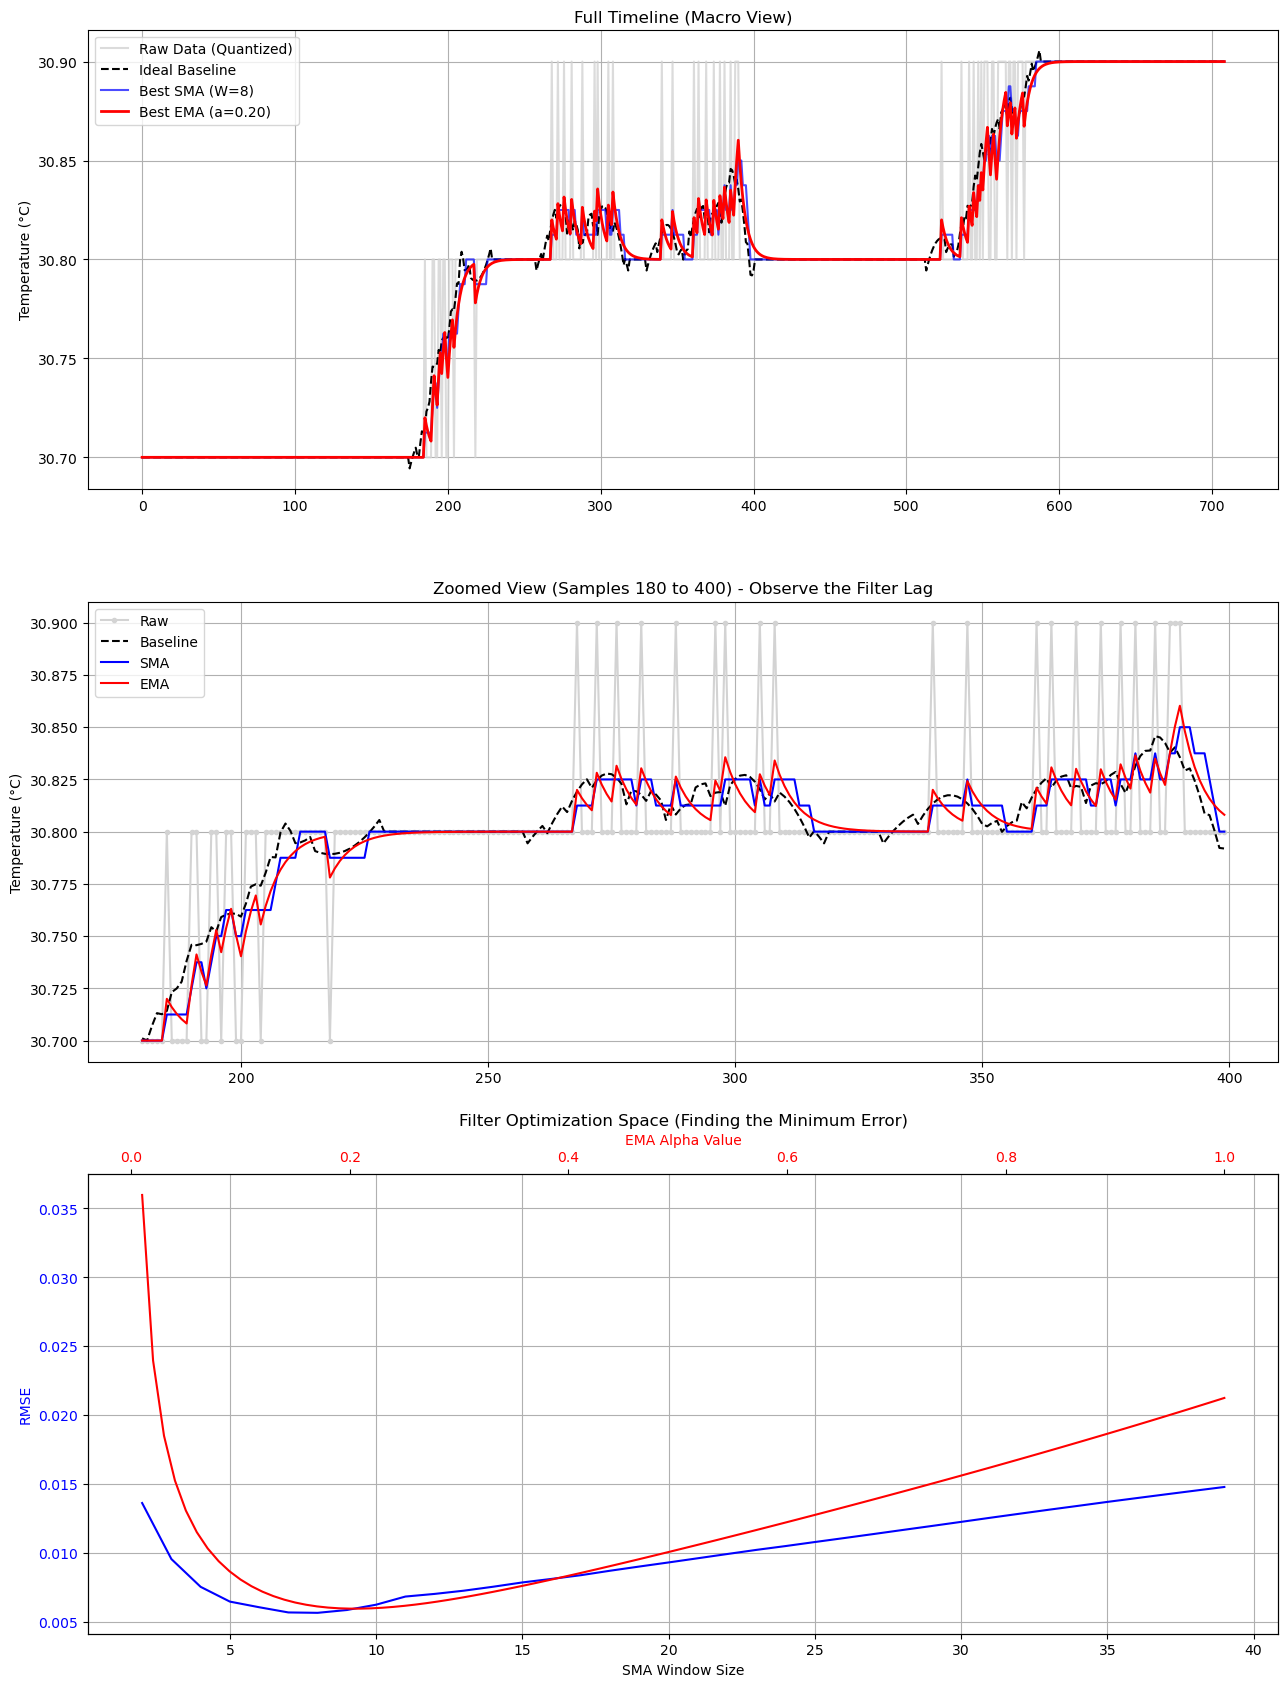

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from sklearn.metrics import mean_squared_error

# 1. Load Data
df = pd.read_csv("raw_temp_data.csv")
raw_data = df['Raw_Temp'].values

# 2. Create "Ground Truth" Baseline (Savitzky-Golay)
# We use a slightly larger window here to smooth out the 0.1C quantization steps
baseline = savgol_filter(raw_data, window_length=21, polyorder=3)

# 3. Define Expanded Parameter Grids (Exhaustive Search)
window_sizes = list(range(2, 40))         # Test every window size from 2 to 40
alpha_values = np.linspace(0.01, 1.0, 100) # Test 100 different alphas between 0.01 and 1.0

# Storage for plotting the error curves later
sma_errors = []
ema_errors = []

best_sma_rmse = float('inf')
best_sma_window = None
best_sma_data = None

best_ema_rmse = float('inf')
best_ema_alpha = None
best_ema_data = None

# 4. Optimize Simple Moving Average (SMA)
for w in window_sizes:
    sma = df['Raw_Temp'].rolling(window=w, min_periods=1).mean().values
    rmse = np.sqrt(mean_squared_error(baseline, sma))
    sma_errors.append(rmse)
    if rmse < best_sma_rmse:
        best_sma_rmse = rmse
        best_sma_window = w
        best_sma_data = sma

# 5. Optimize Exponential Moving Average (EMA)
for a in alpha_values:
    ema = df['Raw_Temp'].ewm(alpha=a, adjust=False).mean().values
    rmse = np.sqrt(mean_squared_error(baseline, ema))
    ema_errors.append(rmse)
    if rmse < best_ema_rmse:
        best_ema_rmse = rmse
        best_ema_alpha = a
        best_ema_data = ema

# 6. Terminal Output
print("--- Rigorous Optimization Results ---")
print(f"Best SMA Window Size: {best_sma_window} (RMSE: {best_sma_rmse:.5f})")
print(f"Best EMA Alpha:       {best_ema_alpha:.3f} (RMSE: {best_ema_rmse:.5f})")

if best_ema_rmse < best_sma_rmse:
    print(f"\nMATHEMATICAL WINNER: EMA filter (Alpha = {best_ema_alpha:.3f})")
else:
    print(f"\nMATHEMATICAL WINNER: SMA filter (Window = {best_sma_window})")

# 7. Advanced Visualization (3 Subplots)
fig, axs = plt.subplots(3, 1, figsize=(14, 18))
fig.tight_layout(pad=6.0)

# --- Plot 1: Full Timeline ---
axs[0].plot(raw_data, label='Raw Data (Quantized)', color='lightgray', alpha=0.8)
axs[0].plot(baseline, label='Ideal Baseline', color='black', linestyle='--', linewidth=1.5)
axs[0].plot(best_sma_data, label=f'Best SMA (W={best_sma_window})', color='blue', alpha=0.7)
axs[0].plot(best_ema_data, label=f'Best EMA (a={best_ema_alpha:.2f})', color='red', linewidth=2)
axs[0].set_title("Full Timeline (Macro View)")
axs[0].set_ylabel("Temperature (°C)")
axs[0].legend()
axs[0].grid(True)

# --- Plot 2: Zoomed-in Timeline (To analyze lag and micro-smoothness) ---
# We will zoom in on samples 180 to 400 based on your screenshot's "action" area
zoom_start = 180
zoom_end = 400
axs[1].plot(range(zoom_start, zoom_end), raw_data[zoom_start:zoom_end], label='Raw', color='lightgray', marker='.')
axs[1].plot(range(zoom_start, zoom_end), baseline[zoom_start:zoom_end], label='Baseline', color='black', linestyle='--')
axs[1].plot(range(zoom_start, zoom_end), best_sma_data[zoom_start:zoom_end], label='SMA', color='blue')
axs[1].plot(range(zoom_start, zoom_end), best_ema_data[zoom_start:zoom_end], label='EMA', color='red')
axs[1].set_title(f"Zoomed View (Samples {zoom_start} to {zoom_end}) - Observe the Filter Lag")
axs[1].set_ylabel("Temperature (°C)")
axs[1].legend()
axs[1].grid(True)

# --- Plot 3: The Optimization Curves (Proof of Method) ---
ax3 = axs[2]
ax3.plot(window_sizes, sma_errors, color='blue', label='SMA RMSE')
ax3.set_xlabel('SMA Window Size')
ax3.set_ylabel('RMSE', color='blue')
ax3.tick_params(axis='y', labelcolor='blue')

ax4 = ax3.twiny() # Create a second X-axis for EMA
ax4.plot(alpha_values, ema_errors, color='red', label='EMA RMSE')
ax4.set_xlabel('EMA Alpha Value', color='red')
ax4.tick_params(axis='x', labelcolor='red')

ax3.set_title("Filter Optimization Space (Finding the Minimum Error)")
ax3.grid(True)

plt.show()